In [3]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

# Load tabular model and processed test dataset
rf_model = joblib.load('models/saved_models/random_forest_env_model.pkl')
X_test_tab = np.load('data/processed/X_test_tab.npy')
feature_names = pd.read_csv('data/processed/feature_names.csv')['0'].tolist()

# Load trained CNN model
cnn_model = tf.keras.models.load_model('models/saved_models/cnn_leaf_model_final.h5')

print("Models and dataset arrays loaded successfully.")

Models and dataset arrays loaded successfully.


### Tabular Explainability with SHAP

<Figure size 1000x600 with 0 Axes>

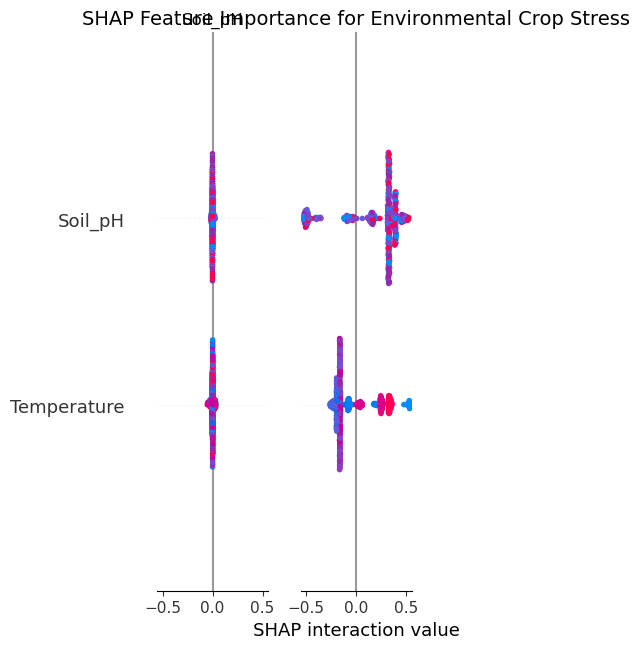

In [4]:
# Initialize TreeExplainer on Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values on a test sample batch (500 samples for computational speed)
sample_data = X_test_tab[:500]
shap_values = explainer.shap_values(sample_data)

# Extract positive class SHAP values for binary classification
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

# Generate SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, sample_data, feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance for Environmental Crop Stress", fontsize=14)
plt.tight_layout()
plt.show()

### Grad-CAM Heatmap Function Definition

In [5]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Construct a sub-model mapping input image to last convolutional layer outputs and predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients of predicted class with respect to output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature map channels by gradient importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

### Generate and Visualize Grad-CAM Overlay

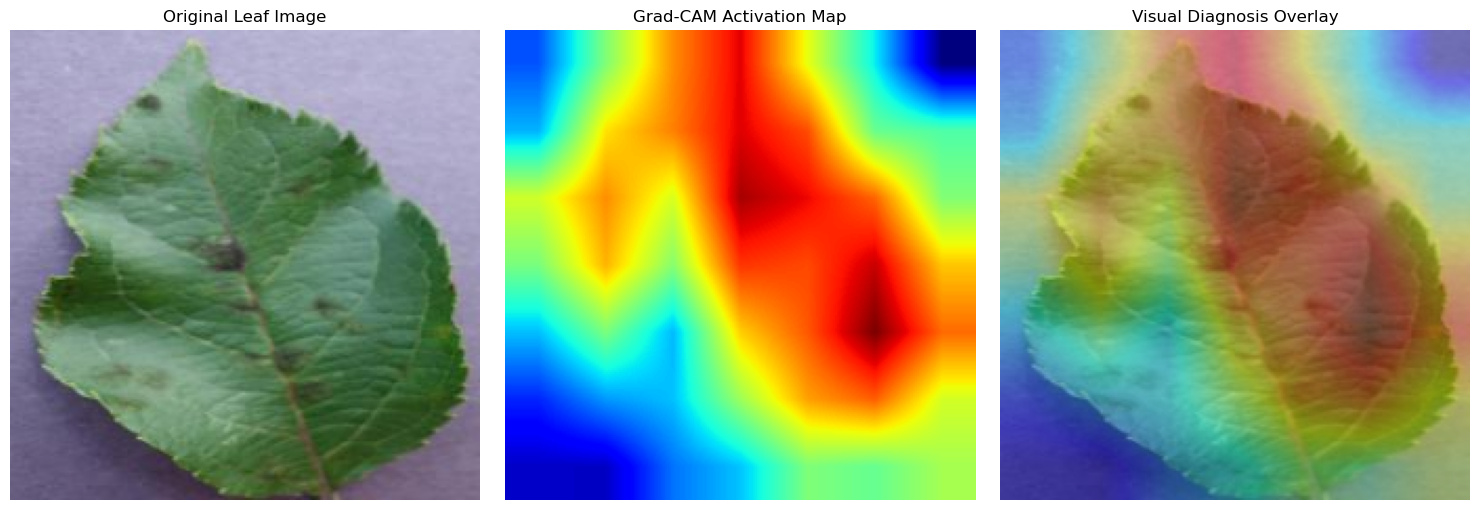

In [10]:
# Identify last convolutional layer in MobileNetV2 base
import glob
last_conv_layer_name = 'Conv_1'  # Standard target layer for MobileNetV2

# Load a test image from PlantVillage directory
test_img_path = glob.glob('plantvillage dataset/color/*/*.JPG')[0]  # Grab first available image

# Load and preprocess image
img = cv2.imread(test_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224))
img_batch = np.expand_dims(img_resized / 255.0, axis=0)

# Generate Heatmap
heatmap = make_gradcam_heatmap(img_batch, cnn_model, last_conv_layer_name)

# Rescale heatmap to original image size
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

# Superimpose heatmap on original image
overlay = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)

# Plot Results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_resized)
axes[0].set_title("Original Leaf Image")
axes[0].axis('off')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title("Grad-CAM Activation Map")
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title("Visual Diagnosis Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()